In [17]:
import time
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression,LogisticRegression,Ridge, Lasso
from sklearn.metrics import mean_squared_error as mse_metric, r2_score as r2_metric
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score as r2_metric, mean_squared_error as mse_metric

Shape: (10299, 35)
Nulls: 0
       tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  \
count       10299.000000       10299.000000       10299.000000   
mean            0.274347          -0.017743          -0.108925   
std             0.067628           0.037128           0.053033   
min            -1.000000          -1.000000          -1.000000   
25%             0.262625          -0.024902          -0.121019   
50%             0.277174          -0.017162          -0.108596   
75%             0.288354          -0.010625          -0.097589   
max             1.000000           1.000000           1.000000   

       tBodyAcc-std()-X  tBodyAcc-std()-Y  tBodyAcc-std()-Z  \
count      10299.000000      10299.000000      10299.000000   
mean          -0.607784         -0.510191         -0.613064   
std            0.438694          0.500240          0.403657   
min           -1.000000         -1.000000         -1.000000   
25%           -0.992360         -0.976990         -0.979137   

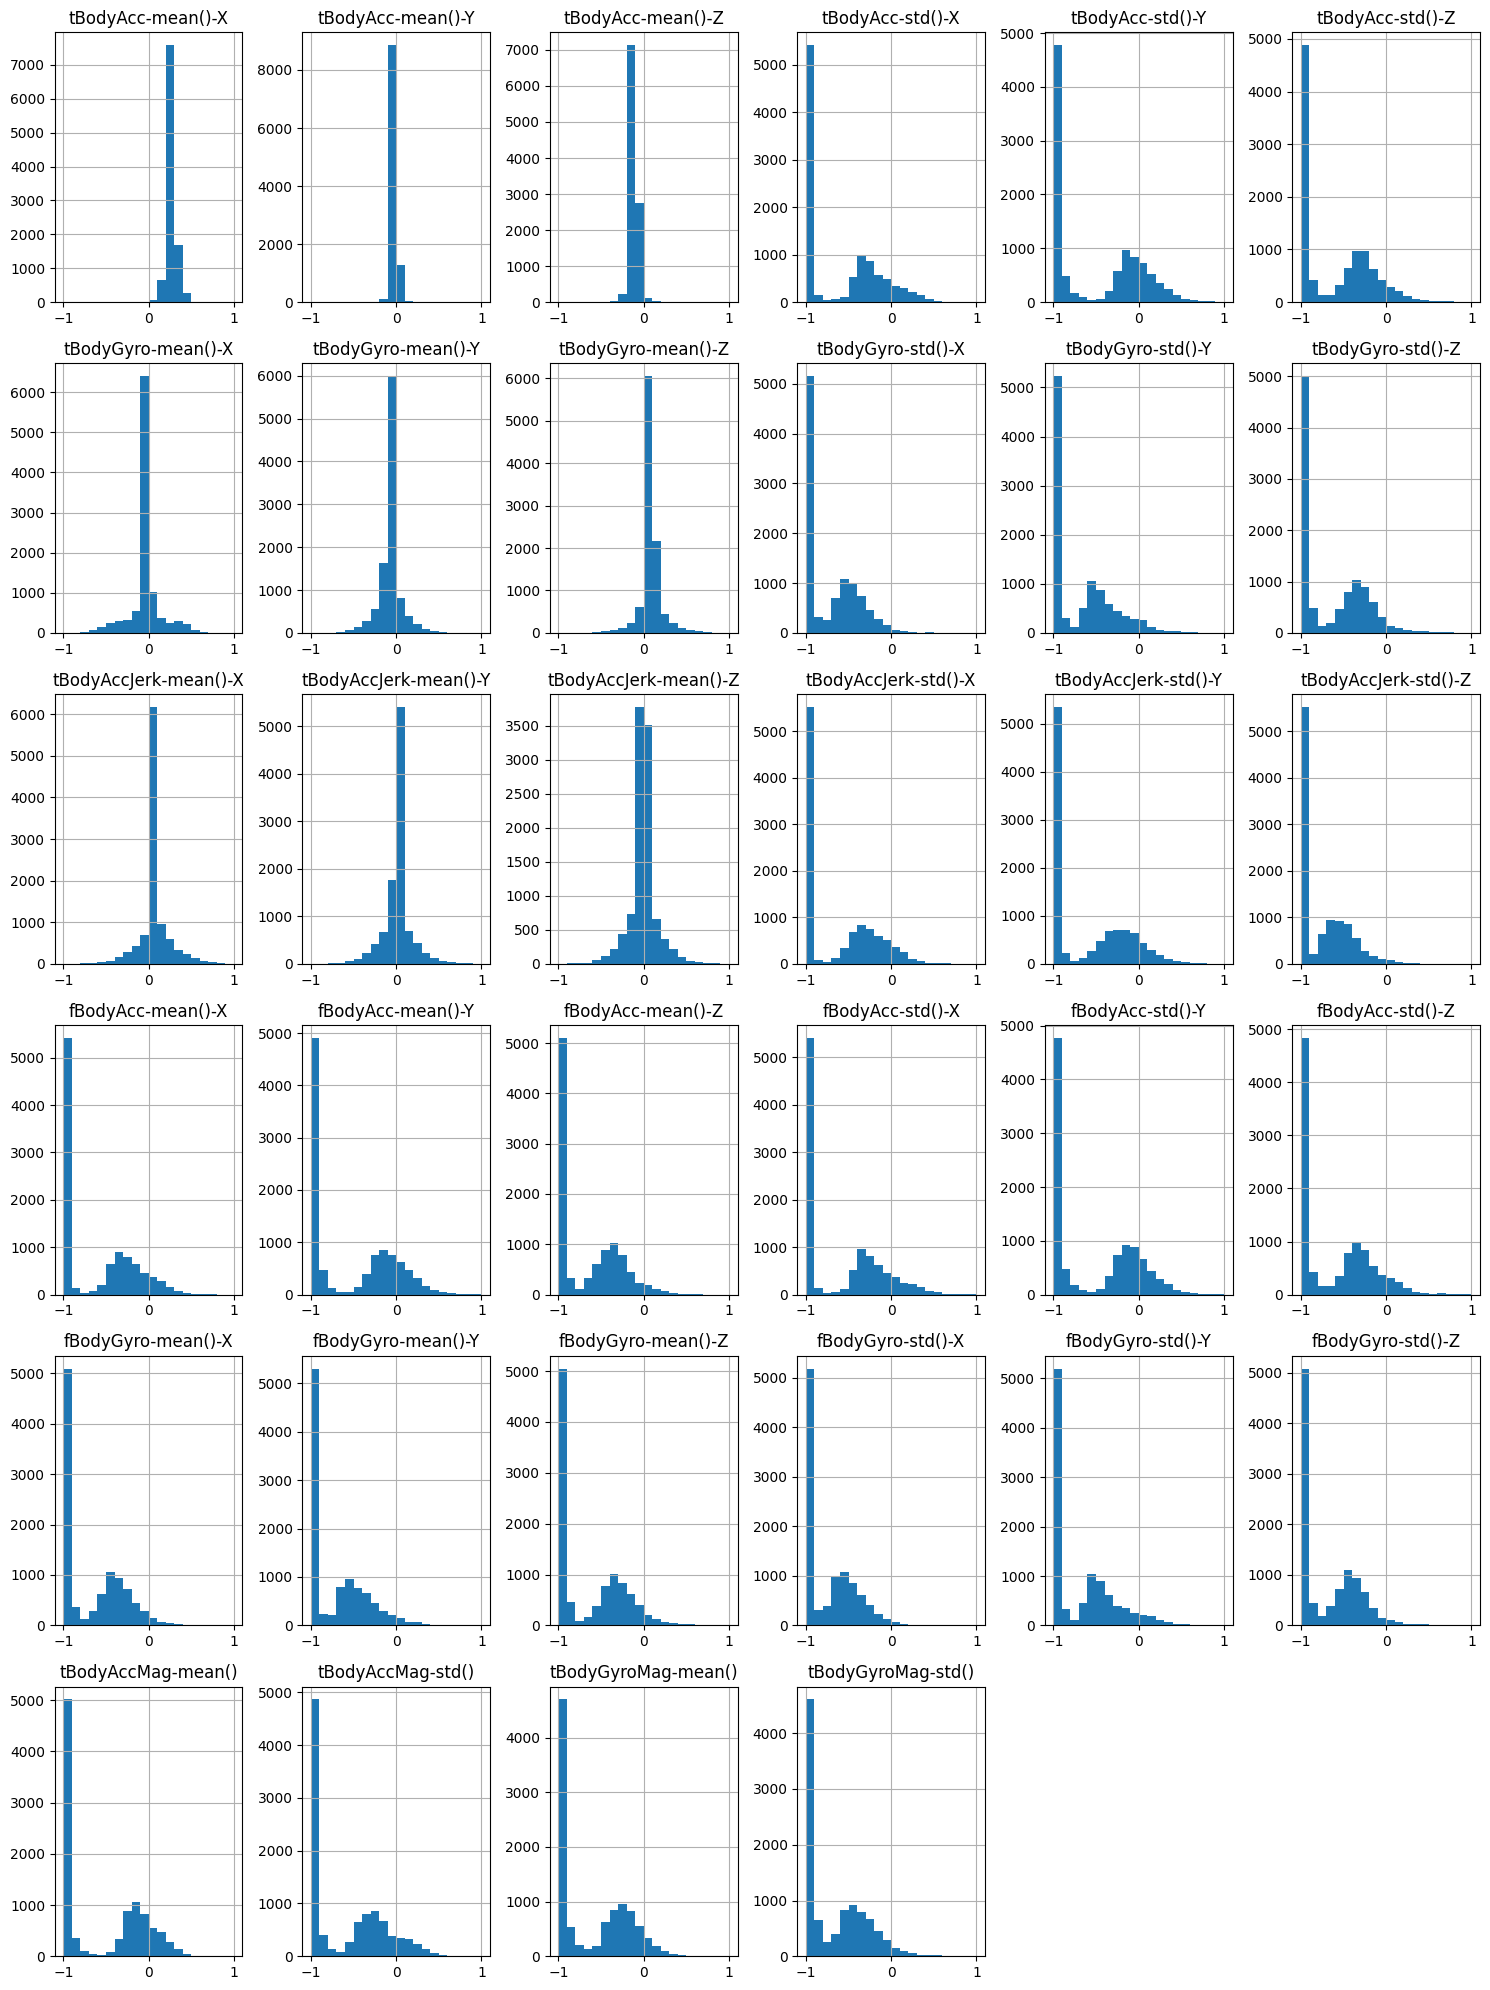

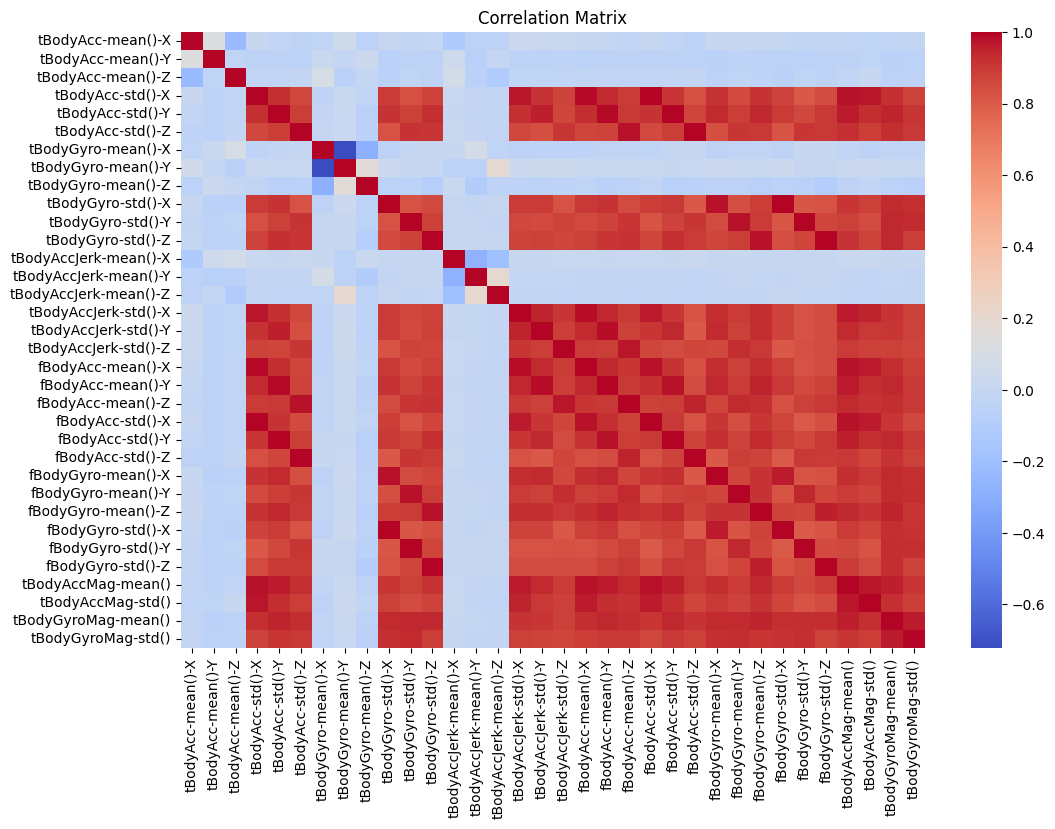

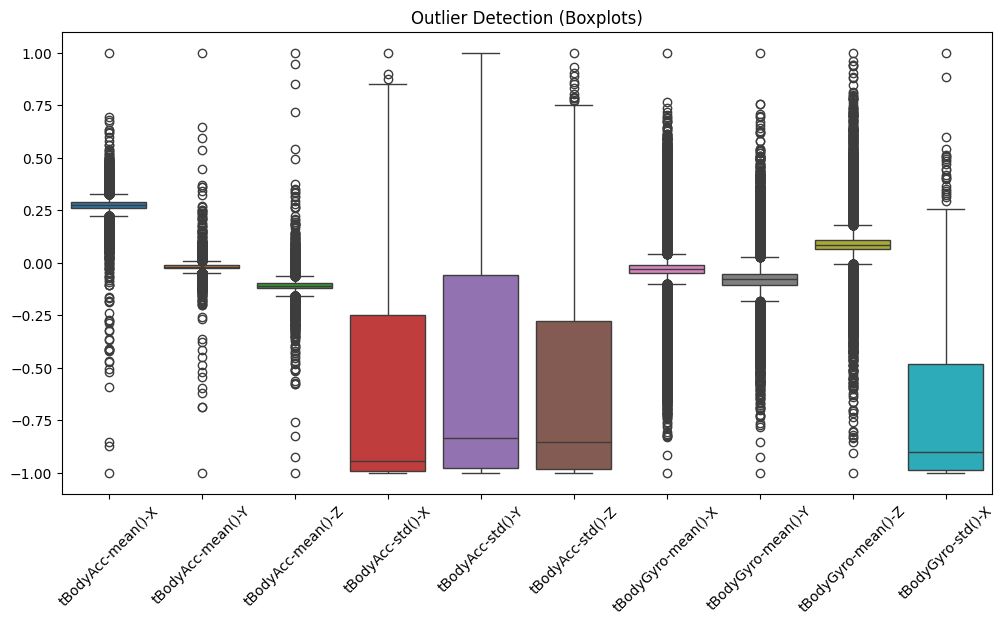

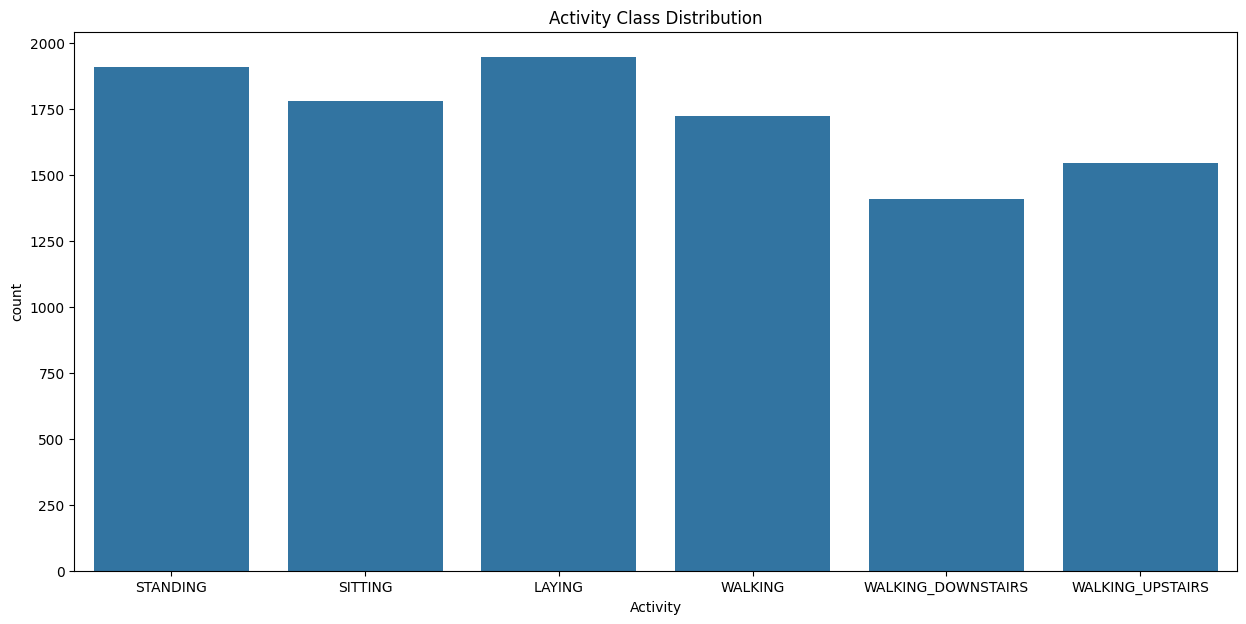

In [18]:

#Part1 

df = pd.read_csv('HAR_35colums_22L-7683 & 22L-6246.csv')

print("Shape:", df.shape)
print("Nulls:", df.isnull().sum().sum())
print(df.describe())


df.hist(figsize=(15, 20), bins=20)
plt.tight_layout(); plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df.select_dtypes(include='number').iloc[:, :10])
plt.xticks(rotation=45)
plt.title("Outlier Detection (Boxplots)")
plt.show()

plt.figure(figsize=(15, 7))
sns.countplot(x='Activity', data=df)
plt.title("Activity Class Distribution")
plt.show()

S G D training on 34 features...
Training Complete (Epochs: 1500)
Training Cost (MSE): 0.3141
Test Set Performance (MSE):  0.6408
Learned Bias (theta0): 3.3292
Learned Weights (First 5 Thetas): [ 1.01111723 -0.24534159 -0.67510077  0.85235308  0.57937732]


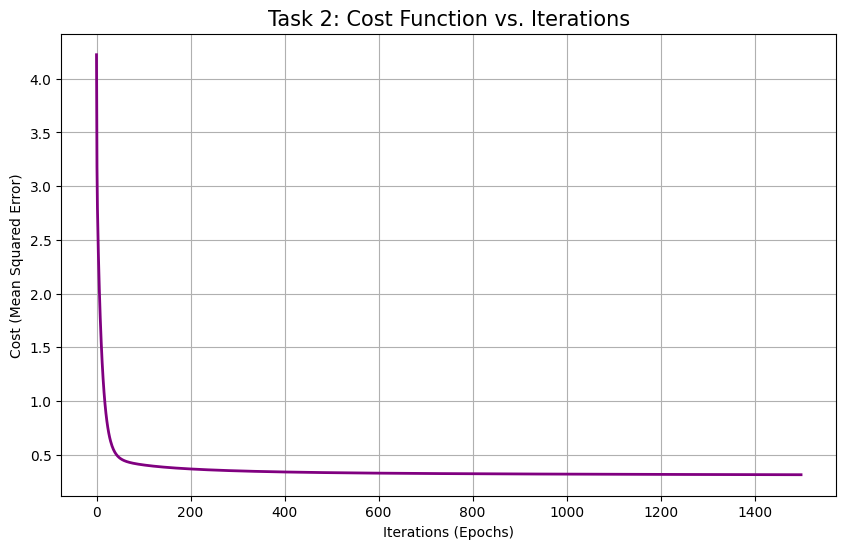

In [19]:
#Part2
X = df.drop('Activity', axis=1).values
y = df['Activity']

y = LabelEncoder().fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

m = X_train.shape[0]


def p(X, theta, bias):
    return np.dot(X, theta) + bias


def gd_from_scratch(X, y, alpha=0.1, epochs=1000):
    n = X.shape[1]
    theta = np.zeros(n)
    bias = 0.0
    costs = []

    for _ in range(epochs):
        pred = p(X, theta, bias)
        error = pred - y

        cost = (1/(2*m)) * np.sum(error ** 2)
        costs.append(cost)

        gradient_theta = (1/m) * np.dot(X.T, error)
        gradient_bias = (1/m) * np.sum(error)

        theta -= alpha * gradient_theta
        bias -= alpha * gradient_bias

    return theta, bias, costs


print("S G D training on 34 features...")
final_theta, final_bias, cost_history = gd_from_scratch(X_train, y_train, alpha=0.1, epochs=1500)

train_mse = cost_history[-1]

y_pred_test = p(X_test, final_theta, final_bias)

test_mse = mean_squared_error(y_test, y_pred_test)

print(f"Training Complete (Epochs: 1500)")
print(f"Training Cost (MSE): {train_mse:.4f}")
print(f"Test Set Performance (MSE):  {test_mse:.4f}")
print(f"Learned Bias (theta0): {final_bias:.4f}")
print(f"Learned Weights (First 5 Thetas): {final_theta[:5]}") # Showing only first 5 to keep output concise


plt.figure(figsize=(10, 6))
plt.plot(cost_history, color='purple', linewidth=2)
plt.title('Task 2: Cost Function vs. Iterations', fontsize=15)
plt.xlabel('Iterations (Epochs)')
plt.ylabel('Cost (Mean Squared Error)')
plt.grid(True)
plt.show()

Scratch Model Evaluation (Full 34 Features) 
Test Set MSE: 0.6408
Test Set R-squared (R²): 0.7718
Learned Bias (theta0): 3.3292

Library Model Evaluation (Full 34 Features) 
Test Set MSE: 0.5700
Test Set R-squared (R²): 0.7970
Library Model Bias (Intercept): 2.7772

Comparison of First 5 Learned Weights (Interpretation)
Feature: tBodyAcc-mean()-X
  Scratch Weight: 1.0111
  Library Weight: 0.4842
Feature: tBodyAcc-mean()-Y
  Scratch Weight: -0.2453
  Library Weight: -0.0677
Feature: tBodyAcc-mean()-Z
  Scratch Weight: -0.6751
  Library Weight: -0.5224
Feature: tBodyAcc-std()-X
  Scratch Weight: 0.8524
  Library Weight: 19.2351
Feature: tBodyAcc-std()-Y
  Scratch Weight: 0.5794
  Library Weight: 4.6218


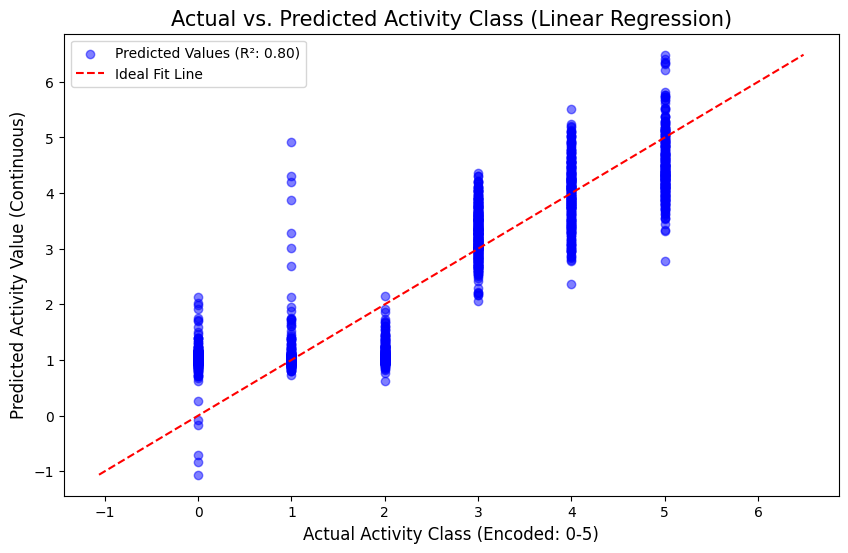

In [21]:
#Part3
X = df.drop('Activity', axis=1).values
y = df['Activity']

y = LabelEncoder().fit_transform(y)

X_train_full, X_test_full, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

m_train = X_train_full.shape[0]


def p(X, theta, bias):
    return np.dot(X, theta) + bias


def gd_from_scratch(X, y, alpha=0.1, epochs=1500):
    n = X.shape[1]
    theta = np.zeros(n)
    bias = 0.0
    costs = []

    for _ in range(epochs):
        pred = p(X, theta, bias)
        error = pred - y

        costs.append((1/(2*m_train)) * np.sum(error ** 2))
        gradient_theta = (1/m_train) * np.dot(X.T, error)
        gradient_bias = (1/m_train) * np.sum(error)

        theta -= alpha * gradient_theta
        bias -= alpha * gradient_bias

    return theta, bias, costs


final_theta, final_bias, cost_history = gd_from_scratch(X_train_full, y_train, alpha=0.1, epochs=1500)

y_pred_scratch = p(X_test_full, final_theta, final_bias)

mse_scratch = mse_metric(y_test, y_pred_scratch)
r2_scratch = r2_metric(y_test, y_pred_scratch)

print("Scratch Model Evaluation (Full 34 Features) ")
print(f"Test Set MSE: {mse_scratch:.4f}")
print(f"Test Set R-squared (R²): {r2_scratch:.4f}")
print(f"Learned Bias (theta0): {final_bias:.4f}")


model = LinearRegression()
model.fit(X_train_full, y_train)
y_pred_library = model.predict(X_test_full)

mse_library = mse_metric(y_test, y_pred_library)
r2_library = r2_metric(y_test, y_pred_library)

print("\nLibrary Model Evaluation (Full 34 Features) ")
print(f"Test Set MSE: {mse_library:.4f}")
print(f"Test Set R-squared (R²): {r2_library:.4f}")
print(f"Library Model Bias (Intercept): {model.intercept_:.4f}")


print("\nComparison of First 5 Learned Weights (Interpretation)")
for i in range(5):
    feature_name = df.columns[i]
    scratch_coeff = final_theta[i]
    library_coeff = model.coef_[i]
    print(f"Feature: {feature_name}")
    print(f"  Scratch Weight: {scratch_coeff:.4f}")
    print(f"  Library Weight: {library_coeff:.4f}")


plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred_library, color='blue', alpha=0.5, label=f'Predicted Values (R²: {r2_library:.2f})')

min_val = min(y_test.min(), y_pred_library.min())
max_val = max(y_test.max(), y_pred_library.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal Fit Line')

plt.title('Actual vs. Predicted Activity Class (Linear Regression)', fontsize=15)
plt.xlabel('Actual Activity Class (Encoded: 0-5)', fontsize=12)
plt.ylabel('Predicted Activity Value (Continuous)', fontsize=12)
plt.legend()
plt.show()

Scratch Logistic Regression (Binary: STANDING vs SITTING)


C:\Users\Window\AppData\Local\Temp\ipykernel_7432\4293554393.py:44: RuntimeWarning: divide by zero encountered in log
  final_cost = (-1 / m_bin) * np.sum(y * np.log(final_h) + (1 - y) * np.log(1 - final_h))
C:\Users\Window\AppData\Local\Temp\ipykernel_7432\4293554393.py:44: RuntimeWarning: invalid value encountered in multiply
  final_cost = (-1 / m_bin) * np.sum(y * np.log(final_h) + (1 - y) * np.log(1 - final_h))
C:\Users\Window\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Final Training Cost (Log Loss): nan
Test Accuracy: 0.4790

Library Logistic Regression (Multi-class: All 6 Activities)
Test Accuracy: 0.8194

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.77      0.72       406
           1       0.73      0.67      0.70       377
           2       0.76      0.70      0.73       354
           3       0.94      0.97      0.96       369
           4       0.97      0.94      0.95       284
           5       0.92      0.93      0.93       270

    accuracy                           0.82      2060
   macro avg       0.83      0.83      0.83      2060
weighted avg       0.82      0.82      0.82      2060

Probability Interpretation (First 10 Test Samples)
Thresholding: Model selects the class with Max Probability.

Sample 1: Actual=WALKING
  Probabilities: {'LAYING': '0.000', 'SITTING': '0.000', 'STANDING': '0.000', 'WALKING': '0.985', 'WALKING_DOWNSTAIRS': '0.006', 'WALKING_UPSTAIRS': '0.008

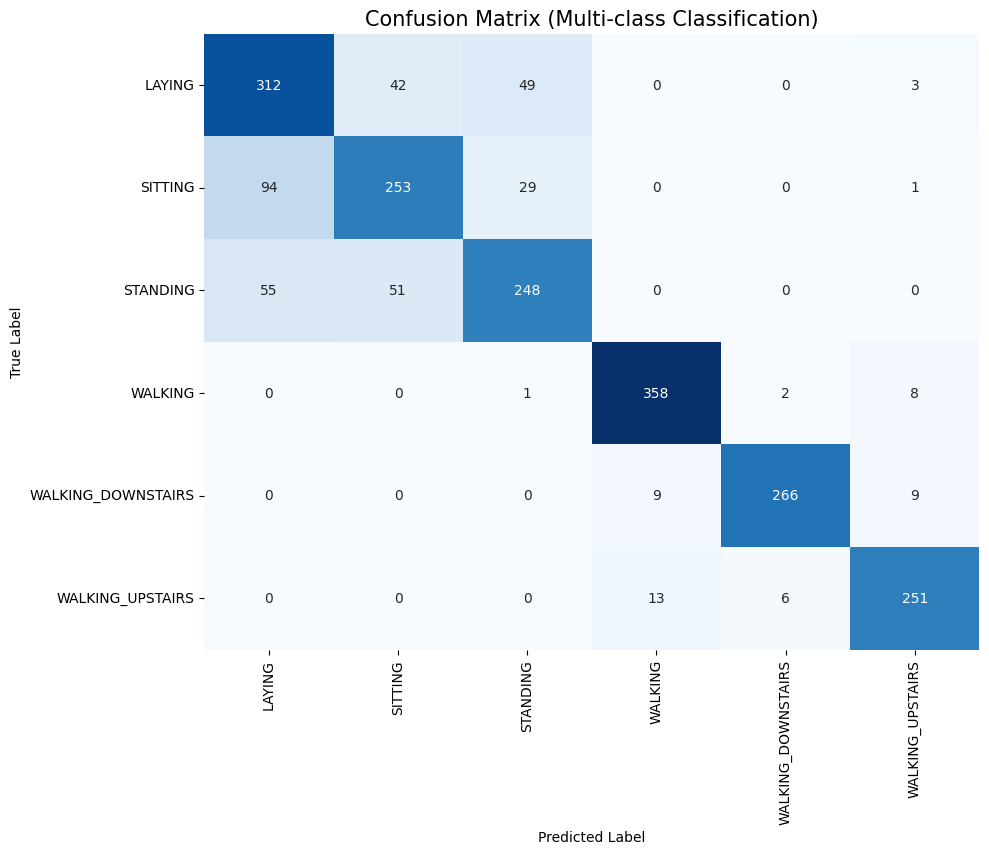

In [22]:
#Part4
le = LabelEncoder()
X_FULL = df.drop('Activity', axis=1).values
y = df['Activity']

y = le.fit_transform(y)

X_train_full, X_test_full, y_train, y_test = train_test_split(X_FULL, y, test_size=0.2, random_state=42)
m_train = X_train_full.shape[0]


print("Scratch Logistic Regression (Binary: STANDING vs SITTING)")

binary_classes = ['STANDING', 'SITTING']
df_binary = df[df['Activity'].isin(binary_classes)].copy()
X_binary = df_binary.drop('Activity', axis=1).values
y_binary = le.transform(df_binary['Activity'])

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_binary, y_binary, test_size=0.2, random_state=42
)
m_bin = X_train_bin.shape[0]

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def logistic_gd_scratch(X, y, alpha=0.01, epochs=2000):
    n = X.shape[1]
    theta = np.zeros(n)
    bias = 0.0

    for _ in range(epochs):
        z = np.dot(X, theta) + bias
        h = sigmoid(z)
        error = h - y

        gradient_theta = (1 / m_bin) * np.dot(X.T, error)
        gradient_bias = (1 / m_bin) * np.sum(error)

        theta -= alpha * gradient_theta
        bias -= alpha * gradient_bias

    final_z = np.dot(X, theta) + bias
    final_h = sigmoid(final_z)
    final_cost = (-1 / m_bin) * np.sum(y * np.log(final_h) + (1 - y) * np.log(1 - final_h))

    return theta, bias, final_cost

theta_scratch, bias_scratch, final_cost = logistic_gd_scratch(X_train_bin, y_train_bin, alpha=0.1, epochs=2000)

z_test = np.dot(X_test_bin, theta_scratch) + bias_scratch
y_prob_scratch = sigmoid(z_test)

y_pred_scratch = (y_prob_scratch >= 0.5).astype(int)
accuracy_scratch = accuracy_score(y_test_bin, y_pred_scratch)

print(f"Final Training Cost (Log Loss): {final_cost:.4f}")
print(f"Test Accuracy: {accuracy_scratch:.4f}")


print("\nLibrary Logistic Regression (Multi-class: All 6 Activities)")

lr_library = LogisticRegression(max_iter=500, multi_class='auto', solver='lbfgs', random_state=42)
lr_library.fit(X_train_full, y_train)

y_pred_library = lr_library.predict(X_test_full)
accuracy_library = accuracy_score(y_test, y_pred_library)

print(f"Test Accuracy: {accuracy_library:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_library))


y_prob_matrix = lr_library.predict_proba(X_test_full[:10])
class_labels = le.classes_

print("Probability Interpretation (First 10 Test Samples)")
print("Thresholding: Model selects the class with Max Probability.")

for i in range(10):
    sample_probs = y_prob_matrix[i]
    predicted_index = np.argmax(sample_probs)
    predicted_label = class_labels[predicted_index]
    actual_label = class_labels[y_test[i]]

    print(f"\nSample {i+1}: Actual={actual_label}")
    prob_dict = dict(zip(class_labels, [f'{p:.3f}' for p in sample_probs]))
    print(f"  Probabilities: {prob_dict}")
    print(f"  Prediction: {predicted_label} (Max Prob)")

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_library)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix (Multi-class Classification)', fontsize=15)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Training Ridge and Lasso Models Across Alpha Range


C:\Users\Window\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.454e+02, tolerance: 2.381e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\Window\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.556e+02, tolerance: 2.381e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\Window\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

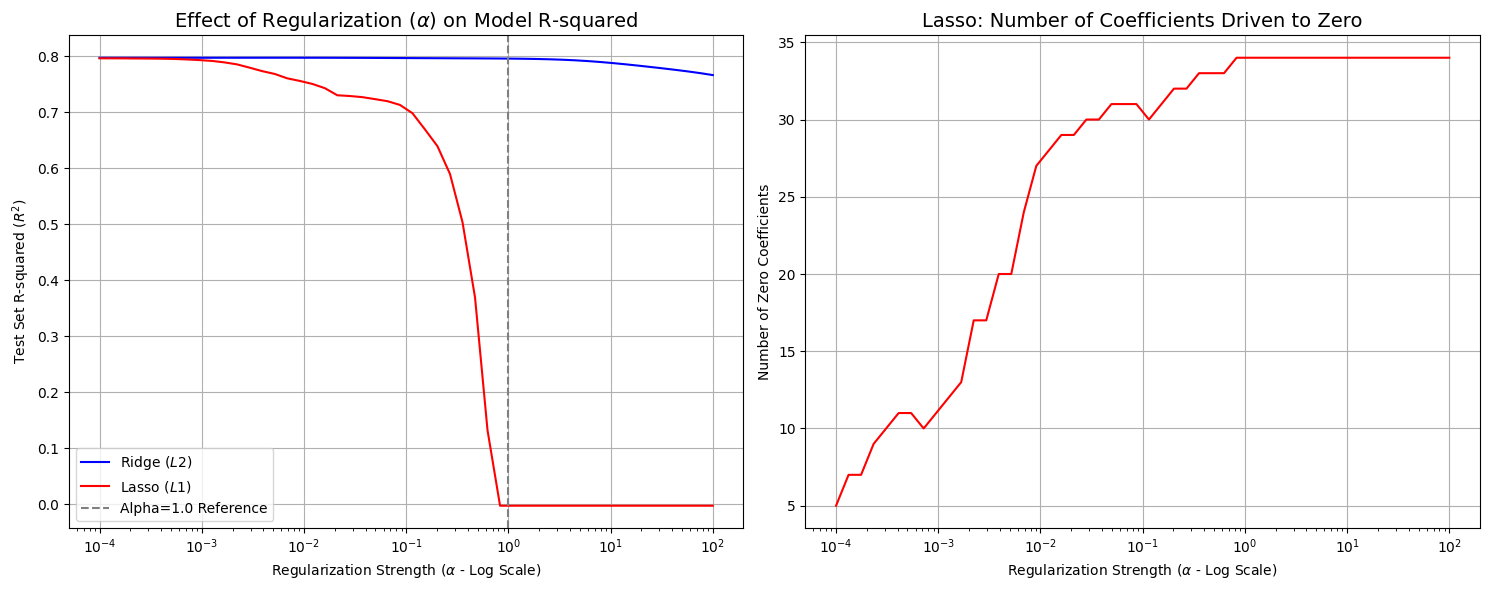


--- Interpretation of Regularization Effect ---
Total Features (Coefficients): 34
----------------------------------------
1. Ridge Model: Shrinks all weights, preventing extreme values.
2. Lasso Model (Alpha=0.01):
    - Coefficients Set to Zero: 27
    - Features Retained: 7

Insight: Lasso achieves **feature selection** by eliminating non-contributing features (driving coefficients to zero), which helps manage model complexity and avoid overfitting on noisy features.


In [23]:
#Part5

alphas = 10**np.linspace(-4, 2, 50)

ridge_r2s = []
lasso_r2s = []
lasso_zero_coeffs = []

print("Training Ridge and Lasso Models Across Alpha Range")

for alpha in alphas:
    ridge = Ridge(alpha=alpha, max_iter=1000)
    ridge.fit(X_train_full, y_train)
    y_pred_ridge = ridge.predict(X_test_full)
    ridge_r2s.append(r2_metric(y_test, y_pred_ridge))

    lasso = Lasso(alpha=alpha, max_iter=5000)
    lasso.fit(X_train_full, y_train)
    y_pred_lasso = lasso.predict(X_test_full)
    lasso_r2s.append(r2_metric(y_test, y_pred_lasso))

    lasso_zero_coeffs.append(np.sum(lasso.coef_ == 0))


plt.figure(figsize=(15, 6))


plt.subplot(1, 2, 1)
plt.plot(alphas, ridge_r2s, label='Ridge ($L2$)', color='blue')
plt.plot(alphas, lasso_r2s, label='Lasso ($L1$)', color='red')
plt.xscale('log')
plt.axvline(x=1.0, color='gray', linestyle='--', label='Alpha=1.0 Reference')
plt.title(r'Effect of Regularization ($\alpha$) on Model R-squared', fontsize=14)
plt.xlabel(r'Regularization Strength ($\alpha$ - Log Scale)')
plt.ylabel(r'Test Set R-squared ($R^2$)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(alphas, lasso_zero_coeffs, color='red')
plt.xscale('log')
plt.title('Lasso: Number of Coefficients Driven to Zero', fontsize=14)
plt.xlabel(r'Regularization Strength ($\alpha$ - Log Scale)')
plt.ylabel('Number of Zero Coefficients')
plt.grid(True)

plt.tight_layout()
plt.show()


high_alpha = 0.01
lasso_final = Lasso(alpha=high_alpha, max_iter=5000).fit(X_train_full, y_train)
zero_count = np.sum(lasso_final.coef_ == 0)

print("\n--- Interpretation of Regularization Effect ---")
print(f"Total Features (Coefficients): {X_train_full.shape[1]}")
print("-" * 40)
print(f"1. Ridge Model: Shrinks all weights, preventing extreme values.")
print(f"2. Lasso Model (Alpha={high_alpha}):")
print(f"    - Coefficients Set to Zero: {zero_count}")
print(f"    - Features Retained: {X_train_full.shape[1] - zero_count}")
print("\nInsight: Lasso achieves **feature selection** by eliminating non-contributing features (driving coefficients to zero), which helps manage model complexity and avoid overfitting on noisy features.")

--- SVM Model Evaluation ---
1. RBF Kernel Model Accuracy: 0.8398
2. Linear Kernel Model Accuracy: 0.8243

Classification Report (RBF Kernel):
                    precision    recall  f1-score   support

            LAYING       0.83      0.72      0.77       406
           SITTING       0.63      0.88      0.74       377
          STANDING       0.81      0.59      0.68       354
           WALKING       0.96      0.99      0.97       369
WALKING_DOWNSTAIRS       0.98      0.98      0.98       284
  WALKING_UPSTAIRS       0.97      0.94      0.96       270

          accuracy                           0.84      2060
         macro avg       0.86      0.85      0.85      2060
      weighted avg       0.85      0.84      0.84      2060



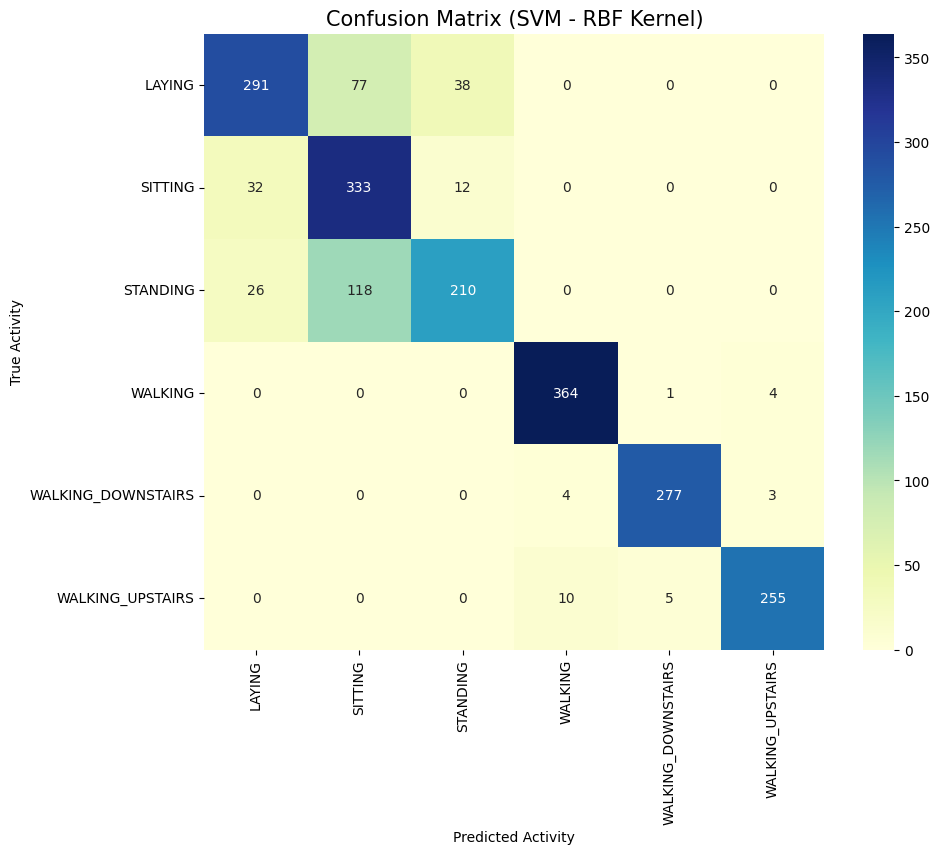

In [25]:
#Part6
le = LabelEncoder()

X_FULL = df.drop('Activity', axis=1).values
y = df['Activity']
y = le.fit_transform(y)

X_train_full, X_test_full, y_train, y_test = train_test_split(X_FULL, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test_full)

class_labels = le.classes_


svm_rbf = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_rbf.fit(X_train_scaled, y_train)
y_pred_rbf = svm_rbf.predict(X_test_scaled)
acc_rbf = accuracy_score(y_test, y_pred_rbf)

svm_linear = SVC(kernel='linear', C=1, random_state=42)
svm_linear.fit(X_train_scaled, y_train)
y_pred_linear = svm_linear.predict(X_test_scaled)
acc_linear = accuracy_score(y_test, y_pred_linear)


print("--- SVM Model Evaluation ---")
print(f"1. RBF Kernel Model Accuracy: {acc_rbf:.4f}")
print(f"2. Linear Kernel Model Accuracy: {acc_linear:.4f}")
print("\nClassification Report (RBF Kernel):")
print(classification_report(y_test, y_pred_rbf, target_names=class_labels))


plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_rbf)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix (SVM - RBF Kernel)', fontsize=15)
plt.xlabel('Predicted Activity')
plt.ylabel('True Activity')
plt.show()

Training and Evaluation of Classifier Models

 Naïve Bayes (Gaussian) Completed. Accuracy: 0.5359 | Time: 0.0205s

 K-Nearest Neighbors (KNN, k=5) Completed. Accuracy: 0.8150 | Time: 2.4672s

 Decision Tree Completed. Accuracy: 0.8044 | Time: 0.5581s

 Random Forest Completed. Accuracy: 0.8985 | Time: 5.5755s

Comparative Performance Analysis

Overall Model Metrics:
Model                          Accuracy        Train Time (s)
-------------------------------------------------------
Naïve Bayes (Gaussian)         0.5359          0.0205    
K-Nearest Neighbors (KNN, k=5) 0.8150          2.4672    
Decision Tree                  0.8044          0.5581    
Random Forest                  0.8985          5.5755    

Conclusion: The **Random Forest** achieved the highest accuracy of 0.8985.


C:\Users\Window\AppData\Local\Temp\ipykernel_7432\2441141245.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models_list, y=accuracies, palette='deep')


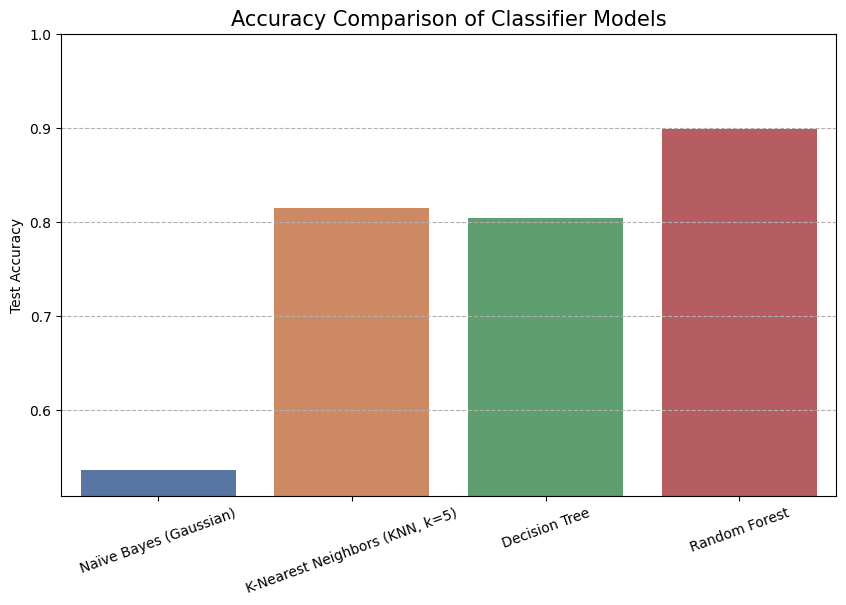

In [26]:
#Part7

le = LabelEncoder()
X_FULL = df.drop('Activity', axis=1).values
y = le.fit_transform(df['Activity'])
X_train_full, X_test_full, y_train, y_test = train_test_split(X_FULL, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test_full)
class_labels = le.classes_
m_test = len(y_test)

results = {}


print("Training and Evaluation of Classifier Models")

models = {
    "Naïve Bayes (Gaussian)": GaussianNB(),
    "K-Nearest Neighbors (KNN, k=5)": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
}

for name, model in models.items():
    start_time = time.time()

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    end_time = time.time()

    accuracy = accuracy_score(y_test, y_pred)
    train_time = end_time - start_time

    results[name] = {
        'Accuracy': accuracy,
        'Time (s)': train_time,
        'Report': classification_report(y_test, y_pred, target_names=class_labels, output_dict=True)
    }

    print(f"\n {name} Completed. Accuracy: {accuracy:.4f} | Time: {train_time:.4f}s")

print("\nComparative Performance Analysis")

comparison_table = []
best_accuracy = 0
best_model = ""

for name, metrics in results.items():
    acc = metrics['Accuracy']
    comparison_table.append([name, f"{acc:.4f}", f"{metrics['Time (s)']:.4f}"])

    if acc > best_accuracy:
        best_accuracy = acc
        best_model = name

print("\nOverall Model Metrics:")
print("{:<30} {:<15} {:<10}".format("Model", "Accuracy", "Train Time (s)"))
print("-" * 55)
for row in comparison_table:
    print("{:<30} {:<15} {:<10}".format(row[0], row[1], row[2]))

print(f"\nConclusion: The **{best_model}** achieved the highest accuracy of {best_accuracy:.4f}.")


models_list = list(results.keys())
accuracies = [results[m]['Accuracy'] for m in models_list]

plt.figure(figsize=(10, 6))
sns.barplot(x=models_list, y=accuracies, palette='deep')
plt.ylim(min(accuracies) * 0.95, 1.0)
plt.title('Accuracy Comparison of Classifier Models', fontsize=15)
plt.ylabel('Test Accuracy')
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--')
plt.show()

In [66]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

ModuleNotFoundError: No module named 'tensorflow'

In [70]:
import sys
!{sys.executable} -m pip install tensorflow matplotlib pandas numpy

ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)
ERROR: No matching distribution found for tensorflow


In [71]:
import tensorflow as tf
print(tf.__version__)

ModuleNotFoundError: No module named 'tensorflow'

SyntaxError: invalid syntax (2636644705.py, line 1)

ModuleNotFoundError: No module named 'sklearn'